In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('Telecom_Tower_Failure_Dataset_10000-1.csv')

# =========================
# 1. DATA EXPLORATION & EDA
# =========================
print("="*60)
print("DATA EXPLORATION & EDA")
print("="*60)

# Basic info
print("\n--- Dataset Shape ---")
print(f"Shape: {df.shape}")

print("\n--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Duplicate Rows ---")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n--- Statistical Summary ---")
print(df.describe())

# Target variable distribution
print("\n--- Target Variable Distribution ---")
print(df['Failure_Within_48Hrs'].value_counts())
print(f"Failure rate: {df['Failure_Within_48Hrs'].mean()*100:.2f}%")


DATA EXPLORATION & EDA

--- Dataset Shape ---
Shape: (10000, 10)

--- Column Names & Data Types ---
Tower_ID                     int64
Temperature_C              float64
Battery_Voltage            float64
Power_Consumption_W          int64
Signal_Strength_Percent      int64
Fan_Speed_RPM                int64
Humidity_Percent             int64
Traffic_Load                 int64
Tower_Age_Years              int64
Failure_Within_48Hrs         int64
dtype: object

--- First 5 Rows ---
   Tower_ID  Temperature_C  Battery_Voltage  Power_Consumption_W  \
0         1           35.6            50.91                 2962   
1         2           43.9            53.33                  736   
2         3           29.0            51.01                 2335   
3         4           39.0            45.62                 2808   
4         5           56.8            51.29                 2590   

   Signal_Strength_Percent  Fan_Speed_RPM  Humidity_Percent  Traffic_Load  \
0                       56  

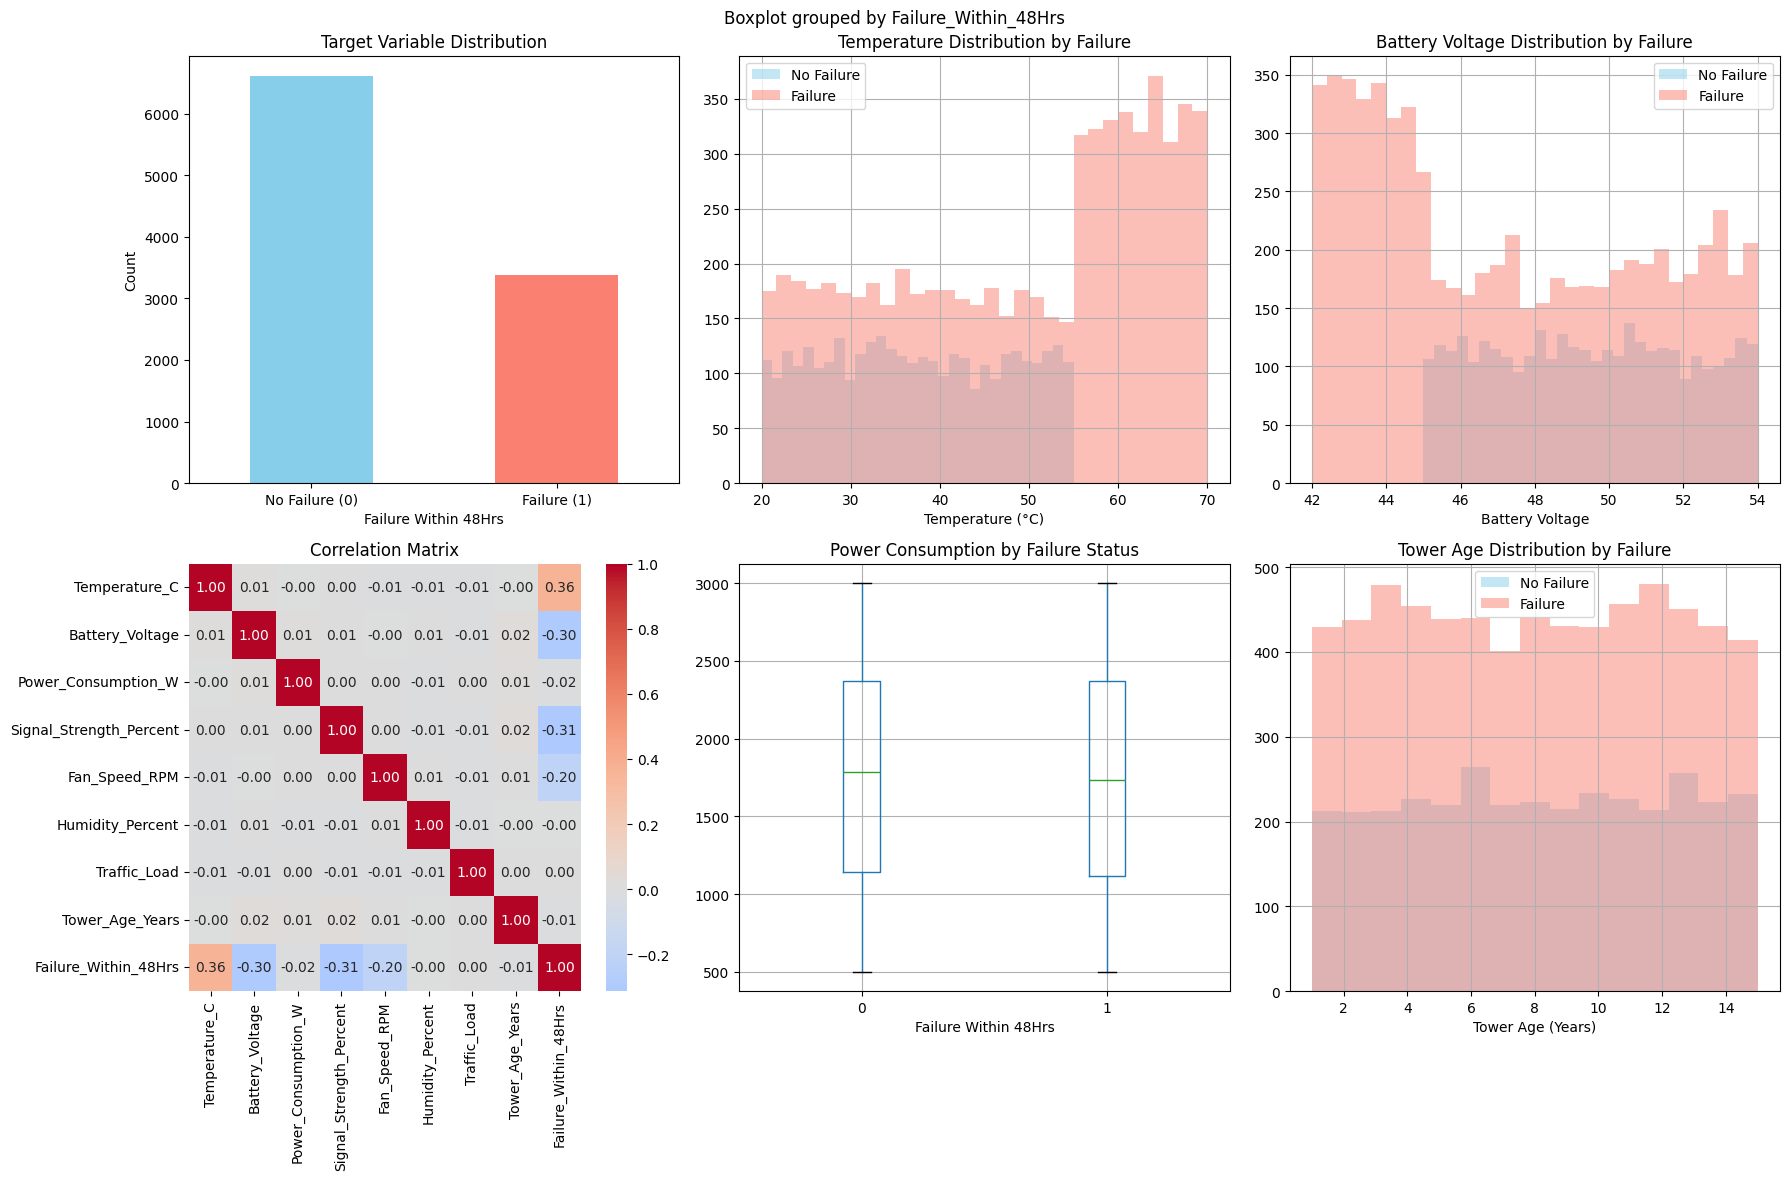

EDA visualizations saved!


In [2]:

# Visualizations for EDA
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Distribution of target variable
ax1 = axes[0, 0]
df['Failure_Within_48Hrs'].value_counts().plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'])
ax1.set_title('Target Variable Distribution')
ax1.set_xlabel('Failure Within 48Hrs')
ax1.set_ylabel('Count')
ax1.set_xticklabels(['No Failure (0)', 'Failure (1)'], rotation=0)

# Temperature distribution by target
ax2 = axes[0, 1]
df[df['Failure_Within_48Hrs']==0]['Temperature_C'].hist(alpha=0.5, bins=30, label='No Failure', ax=ax2, color='skyblue')
df[df['Failure_Within_48Hrs']==1]['Temperature_C'].hist(alpha=0.5, bins=30, label='Failure', ax=ax2, color='salmon')
ax2.set_title('Temperature Distribution by Failure')
ax2.set_xlabel('Temperature (°C)')
ax2.legend()

# Battery Voltage distribution by target
ax3 = axes[0, 2]
df[df['Failure_Within_48Hrs']==0]['Battery_Voltage'].hist(alpha=0.5, bins=30, label='No Failure', ax=ax3, color='skyblue')
df[df['Failure_Within_48Hrs']==1]['Battery_Voltage'].hist(alpha=0.5, bins=30, label='Failure', ax=ax3, color='salmon')
ax3.set_title('Battery Voltage Distribution by Failure')
ax3.set_xlabel('Battery Voltage')
ax3.legend()

# Correlation heatmap
ax4 = axes[1, 0]
corr_matrix = df.drop('Tower_ID', axis=1).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=ax4, fmt='.2f')
ax4.set_title('Correlation Matrix')

# Box plot of Power Consumption by target
ax5 = axes[1, 1]
df.boxplot(column='Power_Consumption_W', by='Failure_Within_48Hrs', ax=ax5)
ax5.set_title('Power Consumption by Failure Status')
ax5.set_xlabel('Failure Within 48Hrs')

# Tower Age distribution by target
ax6 = axes[1, 2]
df[df['Failure_Within_48Hrs']==0]['Tower_Age_Years'].hist(alpha=0.5, bins=15, label='No Failure', ax=ax6, color='skyblue')
df[df['Failure_Within_48Hrs']==1]['Tower_Age_Years'].hist(alpha=0.5, bins=15, label='Failure', ax=ax6, color='salmon')
ax6.set_title('Tower Age Distribution by Failure')
ax6.set_xlabel('Tower Age (Years)')
ax6.legend()

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA visualizations saved!")


In [3]:

# =========================
# 2. DATA CLEANING & PREPROCESSING
# =========================
print("="*60)
print("DATA CLEANING & PREPROCESSING")
print("="*60)

# Check for outliers using IQR method
print("\n--- Outlier Detection (IQR Method) ---")
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('Tower_ID')  # ID column
numeric_cols.remove('Failure_Within_48Hrs')  # Target column

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")

# Check for any impossible/invalid values
print("\n--- Value Range Checks ---")
print(f"Temperature range: {df['Temperature_C'].min()} to {df['Temperature_C'].max()} °C")
print(f"Battery Voltage range: {df['Battery_Voltage'].min()} to {df['Battery_Voltage'].max()} V")
print(f"Signal Strength range: {df['Signal_Strength_Percent'].min()} to {df['Signal_Strength_Percent'].max()}%")
print(f"Humidity range: {df['Humidity_Percent'].min()} to {df['Humidity_Percent'].max()}%")
print(f"Fan Speed range: {df['Fan_Speed_RPM'].min()} to {df['Fan_Speed_RPM'].max()} RPM")
print(f"Tower Age range: {df['Tower_Age_Years'].min()} to {df['Tower_Age_Years'].max()} years")

# All values look reasonable, no cleaning needed for invalid values
# No missing values, no duplicates
print("\n--- Data Quality Assessment ---")
print("✓ No missing values")
print("✓ No duplicate rows")
print("✓ All values within reasonable ranges")
print("✓ No data cleaning required - dataset is clean!")


DATA CLEANING & PREPROCESSING

--- Outlier Detection (IQR Method) ---
Temperature_C: 0 outliers (0.00%)
Battery_Voltage: 0 outliers (0.00%)
Power_Consumption_W: 0 outliers (0.00%)
Signal_Strength_Percent: 0 outliers (0.00%)
Fan_Speed_RPM: 0 outliers (0.00%)
Humidity_Percent: 0 outliers (0.00%)
Traffic_Load: 0 outliers (0.00%)
Tower_Age_Years: 0 outliers (0.00%)

--- Value Range Checks ---
Temperature range: 20.0 to 70.0 °C
Battery Voltage range: 42.0 to 54.0 V
Signal Strength range: 40 to 100%
Humidity range: 20 to 95%
Fan Speed range: 800 to 3500 RPM
Tower Age range: 1 to 15 years

--- Data Quality Assessment ---
✓ No missing values
✓ No duplicate rows
✓ All values within reasonable ranges
✓ No data cleaning required - dataset is clean!


In [4]:

# =========================
# 3. FEATURE ENGINEERING & PREPROCESSING
# =========================
print("="*60)
print("FEATURE ENGINEERING & PREPROCESSING")
print("="*60)

# Drop Tower_ID as it's just an identifier
X = df.drop(['Tower_ID', 'Failure_Within_48Hrs'], axis=1)
y = df['Failure_Within_48Hrs']

print(f"\nFeatures selected: {list(X.columns)}")
print(f"Target variable: Failure_Within_48Hrs")

# Feature engineering - create some derived features
X_processed = X.copy()

# Temperature-Humidity interaction (thermal stress indicator)
X_processed['Temp_Humidity_Interaction'] = X_processed['Temperature_C'] * X_processed['Humidity_Percent'] / 100

# Power efficiency (Power per signal strength)
X_processed['Power_Efficiency'] = X_processed['Power_Consumption_W'] / (X_processed['Signal_Strength_Percent'] + 1)

# Age category
X_processed['Age_Category'] = pd.cut(X_processed['Tower_Age_Years'], 
                                      bins=[0, 5, 10, 15], 
                                      labels=['New', 'Mid', 'Old'])

# Temperature category
X_processed['Temp_Category'] = pd.cut(X_processed['Temperature_C'], 
                                       bins=[0, 35, 55, 100], 
                                       labels=['Cool', 'Moderate', 'Hot'])

print(f"\nNew features created:")
print(f"- Temp_Humidity_Interaction: Thermal stress indicator")
print(f"- Power_Efficiency: Power consumption per signal strength")
print(f"- Age_Category: Categorical age bins")
print(f"- Temp_Category: Categorical temperature bins")

# Encode categorical features
le_age = LabelEncoder()
le_temp = LabelEncoder()
X_processed['Age_Category_Encoded'] = le_age.fit_transform(X_processed['Age_Category'])
X_processed['Temp_Category_Encoded'] = le_temp.fit_transform(X_processed['Temp_Category'])

# Drop original categorical columns
X_processed = X_processed.drop(['Age_Category', 'Temp_Category'], axis=1)

print(f"\nFinal feature set shape: {X_processed.shape}")
print(f"Final features: {list(X_processed.columns)}")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set size: {X_train.shape[0]} ({X_train.shape[0]/len(X_processed)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X_processed)*100:.1f}%)")
print(f"Train failure rate: {y_train.mean()*100:.2f}%")
print(f"Test failure rate: {y_test.mean()*100:.2f}%")


FEATURE ENGINEERING & PREPROCESSING

Features selected: ['Temperature_C', 'Battery_Voltage', 'Power_Consumption_W', 'Signal_Strength_Percent', 'Fan_Speed_RPM', 'Humidity_Percent', 'Traffic_Load', 'Tower_Age_Years']
Target variable: Failure_Within_48Hrs

New features created:
- Temp_Humidity_Interaction: Thermal stress indicator
- Power_Efficiency: Power consumption per signal strength
- Age_Category: Categorical age bins
- Temp_Category: Categorical temperature bins

Final feature set shape: (10000, 12)
Final features: ['Temperature_C', 'Battery_Voltage', 'Power_Consumption_W', 'Signal_Strength_Percent', 'Fan_Speed_RPM', 'Humidity_Percent', 'Traffic_Load', 'Tower_Age_Years', 'Temp_Humidity_Interaction', 'Power_Efficiency', 'Age_Category_Encoded', 'Temp_Category_Encoded']

Train set size: 8000 (80.0%)
Test set size: 2000 (20.0%)
Train failure rate: 66.12%
Test failure rate: 66.15%


RANDOM FOREST CLASSIFIER TRAINING

--- Initial Model (Default Parameters) ---
Cross-validation accuracy: 1.0000 (+/- 0.0000)

--- Feature Importance ---
                  feature  importance
          Battery_Voltage    0.249212
  Signal_Strength_Percent    0.243764
            Temperature_C    0.201355
            Fan_Speed_RPM    0.156691
    Temp_Category_Encoded    0.059138
Temp_Humidity_Interaction    0.032705
         Power_Efficiency    0.032029
      Power_Consumption_W    0.010810
         Humidity_Percent    0.006994
             Traffic_Load    0.004137
          Tower_Age_Years    0.002436
     Age_Category_Encoded    0.000729


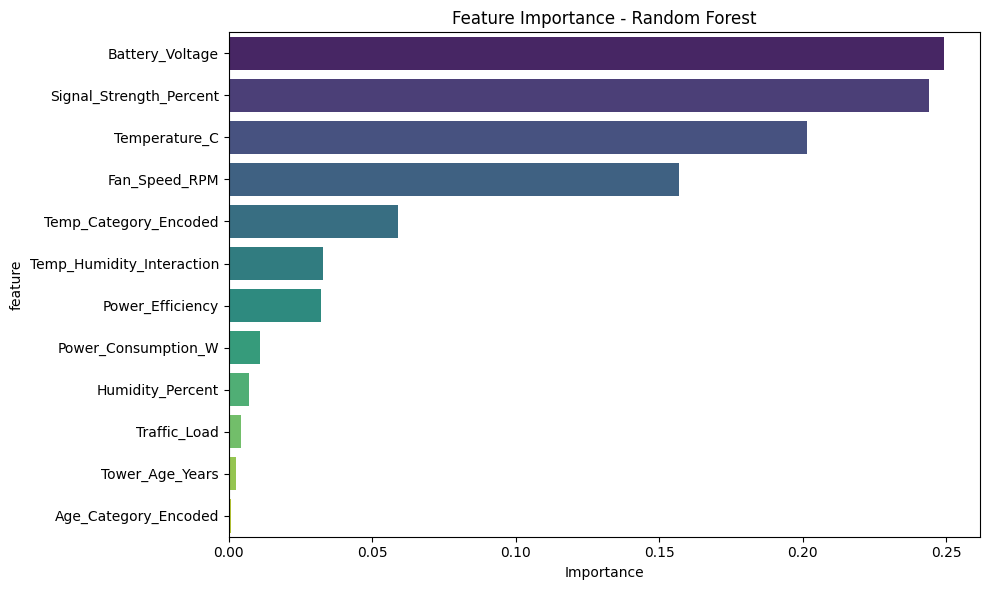

Feature importance plot saved!


In [5]:

# =========================
# 4. MODEL TRAINING - Random Forest Classifier
# =========================
print("="*60)
print("RANDOM FOREST CLASSIFIER TRAINING")
print("="*60)

# Initial model with default parameters
rf_initial = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_initial.fit(X_train, y_train)

# Cross-validation scores
cv_scores = cross_val_score(rf_initial, X_train, y_train, cv=5, scoring='accuracy')
print(f"\n--- Initial Model (Default Parameters) ---")
print(f"Cross-validation accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': X_processed.columns,
    'importance': rf_initial.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n--- Feature Importance ---")
print(feature_importance.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved!")


In [6]:

# Hyperparameter tuning with GridSearchCV
print("\n--- Hyperparameter Tuning (GridSearchCV) ---")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Use a smaller grid for faster execution
param_grid_small = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid_small,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

# Final model with best parameters
best_rf = grid_search.best_estimator_

# Predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

# =========================
# 5. MODEL EVALUATION
# =========================
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

print("\n--- Training Set Performance ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_train, best_rf.predict_proba(X_train)[:, 1]):.4f}")

print("\n--- Test Set Performance ---")
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"Accuracy: {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall: {test_recall:.4f}")
print(f"F1-Score: {test_f1:.4f}")
print(f"ROC-AUC: {test_roc_auc:.4f}")

print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_test, y_test_pred, target_names=['No Failure', 'Failure']))



--- Hyperparameter Tuning (GridSearchCV) ---
Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 1.0000

MODEL EVALUATION

--- Training Set Performance ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000

--- Test Set Performance ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC-AUC: 1.0000

--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

  No Failure       1.00      1.00      1.00       677
     Failure       1.00      1.00      1.00      1323

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



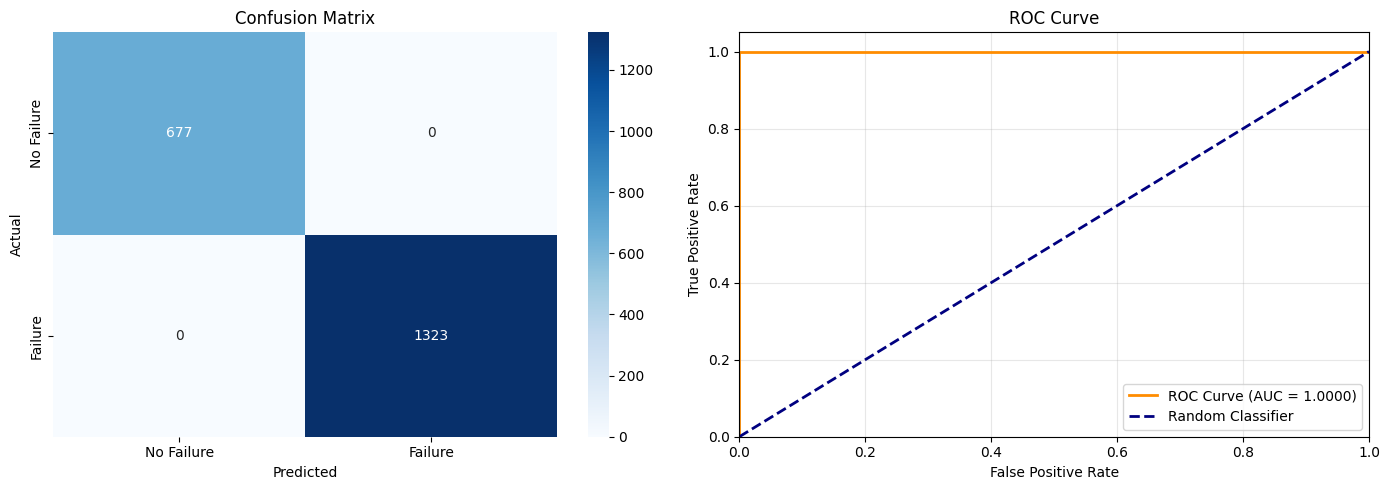

Model evaluation plots saved!


In [7]:

# Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Failure', 'Failure'],
            yticklabels=['No Failure', 'Failure'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model evaluation plots saved!")


In [8]:

import json
import pickle

# =========================
# 6. SAVE MODEL & METRICS
# =========================
print("="*60)
print("SAVING MODEL & METRICS")
print("="*60)

# Save the trained model
model_path = 'model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_rf, f)
print(f"✓ Model saved to: {model_path}")

# Save metrics to JSON
metrics = {
    "model": "RandomForestClassifier",
    "best_parameters": grid_search.best_params_,
    "cross_validation": {
        "mean_accuracy": float(cv_scores.mean()),
        "std_accuracy": float(cv_scores.std())
    },
    "training_metrics": {
        "accuracy": float(accuracy_score(y_train, y_train_pred)),
        "precision": float(precision_score(y_train, y_train_pred)),
        "recall": float(recall_score(y_train, y_train_pred)),
        "f1_score": float(f1_score(y_train, y_train_pred)),
        "roc_auc": float(roc_auc_score(y_train, best_rf.predict_proba(X_train)[:, 1]))
    },
    "test_metrics": {
        "accuracy": float(test_accuracy),
        "precision": float(test_precision),
        "recall": float(test_recall),
        "f1_score": float(test_f1),
        "roc_auc": float(test_roc_auc)
    },
    "confusion_matrix": {
        "true_negatives": int(cm[0, 0]),
        "false_positives": int(cm[0, 1]),
        "false_negatives": int(cm[1, 0]),
        "true_positives": int(cm[1, 1])
    },
    "feature_importance": feature_importance.set_index('feature')['importance'].to_dict(),
    "dataset_info": {
        "total_samples": int(len(df)),
        "train_samples": int(len(X_train)),
        "test_samples": int(len(X_test)),
        "num_features": int(X_processed.shape[1]),
        "features": list(X_processed.columns)
    }
}

metrics_path = 'metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"✓ Metrics saved to: {metrics_path}")

# Print metrics summary
print(f"\n--- Metrics Summary ---")
print(json.dumps(metrics, indent=4))


SAVING MODEL & METRICS
✓ Model saved to: model.pkl
✓ Metrics saved to: metrics.json

--- Metrics Summary ---
{
    "model": "RandomForestClassifier",
    "best_parameters": {
        "max_depth": 10,
        "max_features": "sqrt",
        "min_samples_leaf": 1,
        "min_samples_split": 5,
        "n_estimators": 200
    },
    "cross_validation": {
        "mean_accuracy": 1.0,
        "std_accuracy": 0.0
    },
    "training_metrics": {
        "accuracy": 1.0,
        "precision": 1.0,
        "recall": 1.0,
        "f1_score": 1.0,
        "roc_auc": 1.0
    },
    "test_metrics": {
        "accuracy": 1.0,
        "precision": 1.0,
        "recall": 1.0,
        "f1_score": 1.0,
        "roc_auc": 1.0
    },
    "confusion_matrix": {
        "true_negatives": 677,
        "false_positives": 0,
        "false_negatives": 0,
        "true_positives": 1323
    },
    "feature_importance": {
        "Battery_Voltage": 0.24921212937653595,
        "Signal_Strength_Percent": 0.24376